## Cell Phone Lens System Example ##

In this example, we will do some simple analysis of Example 3 of the Cell Phone System described in US Patent 7535658.  

In [21]:
addpath(genpath('../../'));
pwd




ans = '/Users/jeremy/Downloads/work/prtLab/docs/source'

First let's load this example, which contains several asphere lenses.

In [22]:
T = exampleCellPhoneLensEx3System();

disp(T);

    Radius    Thickness     SurfaceType     SurfaceData     MaterialType     IndexData        AxisData      CoatingData 
    ______    _________    _____________    ____________    ____________    ____________    ____________    ____________

     1.948         0       "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
     9.999       0.9       "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
    -1.925       0.8       "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
    -6.492      0.59       "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
     6.217      0.11       "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
    20.578      0.66       "odd_asphere"    {1x1 struct}    "isotropic"     {1x1 struct}    {1x1 struct}    {1x1 struct}
     1.399      0.15       "odd

These are all isotropic materials, but that does not mean there isn't value in doing some polarization ray tracing.  

Let's do some visualization of this, just so we know what we are dealing with.  

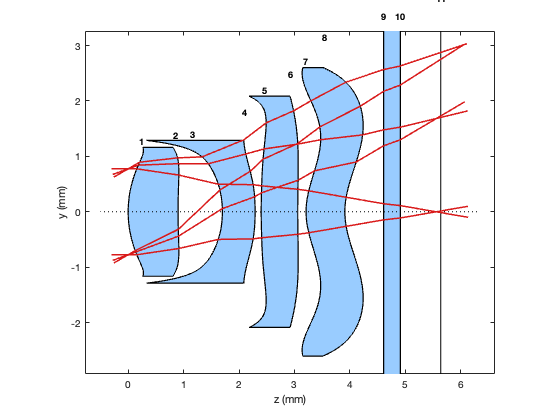

In [23]:


Ein = [1;0];
k = [0; sin(30*pi/180); cos(30*pi/180)];
x1 = [0; 0.775; 0];
x2 = [0; -0.775; 0];

options = prtDefaultOptions();
options.minRelativeFlux = .25;

d1 = polarizationRayTrace(T, k, x1, Ein, options);
d2 = polarizationRayTrace(T, k, x2, Ein, options);



Tplot = updateClearAperturesFromRayTrace(T, {d1, d2}, ...
    'Margin', 1.30, ...
    'Minimum', 0.25);

T = Tplot;

figure;
k2 = [0; sin(20*pi/180); cos(20*pi/180)];
k3 = [0; 0; 1];
d3 = polarizationRayTrace(T, k2, x1, Ein, options);
d4 = polarizationRayTrace(T, k2, x2, Ein, options);
d5 = polarizationRayTrace(T, k3, x1, Ein, options);
d6 = polarizationRayTrace(T, k3, x2, Ein, options);
plotPrtLensCrossSection(Tplot);
plotPrtRayTrace({d1, d2, d3, d4, d5, d6});

You can see the fun shapes of this system, and some field curvature.  This is not a ray tracing program.  In theory you could interface with real optical design software to provide ray intercepts, positions, and surface normals, but that is not currently supported.

Note that I defined a separate Tplot above.  That is not strictly necessary, but the clear apertures used are only for plotting purposes.  The actual polarization ray tracing code does not care about clear apertures, it assumes they are always large enough to propagate the next ray.

Now let's look at what happens to the exit pupil of this system if you place it between two crossed polarizers.

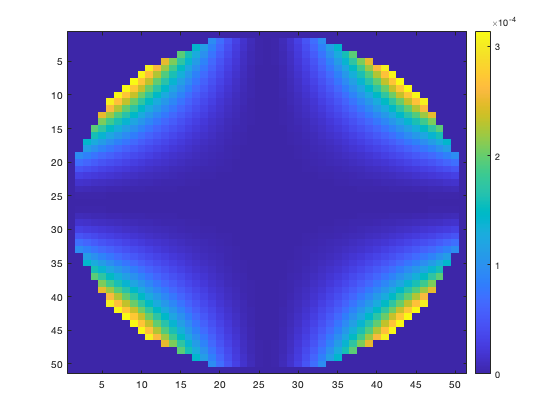

In [24]:

[X,Y] = meshgrid(linspace(-.775,.775,51)); % assume 10mm diameter pupil
[~,RHO] = cart2pol(X,Y);
ftr = RHO<=0.775;
E_in = [1;0];
k_in = [0; 0; 1];

coord = struct('type',"doublePole", ...
    'a_loc',k_in, ...
    'x_o',[1;0;0]);

for ii=1:size(X,1)
    for jj=1:size(X,2)
        pos_in = [X(ii,jj); Y(ii,jj); 0];
        rayOutput = polarizationRayTrace(T, k_in, pos_in, E_in, options);
        if ~isempty(rayOutput.finalRayIds)
        P_tot = rayOutput.rays(rayOutput.finalRayIds(1)).P;
        J = transformPtoJones(P_tot, k_in, rayOutput.rays(rayOutput.finalRayIds(1)).k, coord);
        Jall(ii,jj,:,:) = J;

        E_out = [0,1]*J*E_in;
        I_out(ii,jj) = E_out.^2;
        else
            Jall(ii,jj,:,:) = zeros(2,2);
            I_out(ii,jj) = 0.0;
        end   
    end
end

figure;imagesc(I_out.*ftr); colorbar;

You can see the classic Maltese Cross Pattern.  The value is quite low so it is not an issue for this lens, but this is just an example of how to use prtLab to do this analysis.

The other use of this example, as mentioned in PLAOS Chapter 11, is to show possible artifacts in the Jones pupil output due to choice of coordinate systems. 

First, let's show the local x coordinates for double pole coordinates.  

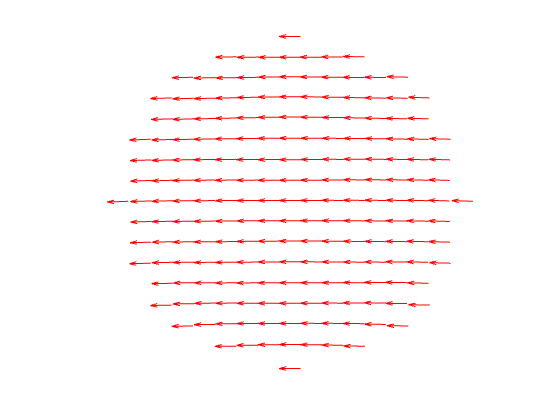

In [25]:
%% Test coordinate plots
tta = 7 ;
k_in = [0; sin(tta*pi/180); cos(tta*pi/180)];
[X,Y] = meshgrid(linspace(-0.741676704231623,0.741676704231623,17));

Ein = [1;0]; 

x_loc = [];
y_loc = [];
k_loc = [];

[~, RHO] = cart2pol(X,Y);
ftr = RHO <= 0.741676704231623;

ii=9;jj=9; rayOutput = polarizationRayTrace(T, k_in, [X(ii,jj) ; Y(ii,jj) ; 0], Ein);
k_chief = rayOutput.rays(end).k ;

coord = struct('type',"doublePole", ...
    'a_loc',k_in, ...
    'x_o',[1;0;0]);



for ii=1:size(X,1)
    for jj=1:size(X,2)
        rayOutput = polarizationRayTrace(T, k_in, [X(ii,jj) ; Y(ii,jj) ; 0], Ein, options);

        finalRay = rayOutput.rays(rayOutput.finalRayIds(1));
        P_tot = finalRay.P;
        k_o = rayOutput.rays(rayOutput.finalRayIds(1)).k;
        % Use this function to get the local basis for k_o based on choices in coord
        [J, x_o, y_o] = transformPtoJones(P_tot, k_in, k_o, coord);
 
        % Test for singularity
        if isreal(finalRay.k) && ftr(ii,jj) == 1
        x_loc = [x_loc ; x_o'];
        y_loc = [y_loc ; y_o'];
        k_loc = [k_loc ; k_o'];
        end

    end
end


% Plot x basis vectors on a sphere, but with a 2D view by looking at the sphere from the chief ray direction.
opts_k = struct('showSphere', false, 'arrowScale', 0.02, ...
    'sphereAlpha', 0.1, 'lineWidth', 1, 'viewAngle', [0, tta, -90]);
figure;plotBasisVectorsOnSphere(k_loc,x_loc, [], opts_k); axis off;


This snippet of code is filling the entrance pupil of the system for an angle of incidence of 7 degrees and storing the local coordinate system at the image plane based on double pole coordinates.  Because of the choice of a_loc, there is no singularity in the coordinate system showing up.

But, if one uses s/p coordinates for the local exit coordinates, a singularity will be seen at the bottom, as k_o approaches normal incidence:

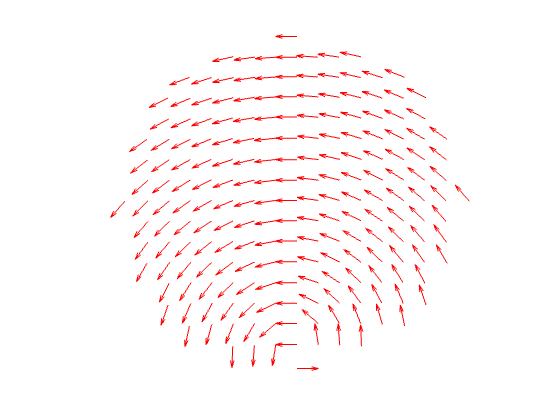

In [26]:
%% Test coordinate plots
tta = 7 ;
k_in = [0; sin(tta*pi/180); cos(tta*pi/180)];
[X,Y] = meshgrid(linspace(-0.741676704231623,0.741676704231623,17));

Ein = [1;0]; 

x_loc = [];
y_loc = [];
k_loc = [];

[~, RHO] = cart2pol(X,Y);
ftr = RHO <= 0.741676704231623;

ii=9;jj=9; rayOutput = polarizationRayTrace(T, k_in, [X(ii,jj) ; Y(ii,jj) ; 0], Ein);
k_chief = rayOutput.rays(end).k ;

% This is the only difference from the last snipped
coord = struct('type',"sp", ...
    'normal',[0;0;1]);



for ii=1:size(X,1)
    for jj=1:size(X,2)
        rayOutput = polarizationRayTrace(T, k_in, [X(ii,jj) ; Y(ii,jj) ; 0], Ein, options);

        finalRay = rayOutput.rays(rayOutput.finalRayIds(1));
        P_tot = finalRay.P;
        k_o = rayOutput.rays(rayOutput.finalRayIds(1)).k;
        % Use this function to get the local basis for k_o based on choices in coord
        [J, x_o, y_o] = transformPtoJones(P_tot, k_in, k_o, coord);
 
        % Test for singularity
        if isreal(finalRay.k) && ftr(ii,jj) == 1
        x_loc = [x_loc ; x_o'];
        y_loc = [y_loc ; y_o'];
        k_loc = [k_loc ; k_o'];
        end

    end
end


% Plot x basis vectors on a sphere, but with a 2D view by looking at the sphere from the chief ray direction.
opts_k = struct('showSphere', false, 'arrowScale', 0.02, ...
    'sphereAlpha', 0.1, 'lineWidth', 1, 'viewAngle', [0, tta, -90]);
figure;plotBasisVectorsOnSphere(k_loc,x_loc, [], opts_k); axis off;


Here you can see the singularity as the output k vector approaches normal incidence.  WHile not shown, this can lead to artifacts in the Jones pupil that may appear interesting, but are really just a consequence of the local coordinate transformation.